# **Flow 4: Training, Evaluasi & Benchmarking Model**

## **4.1 Setup & Split Data Train/Val/Test**

**Teknik Code:** Load config/edge_index/speed_matrix + split sequential berbasis tanggal (5 hari train, 1 val, 1 test)

**Cara Kerja:** Data dibagi berurutan berdasarkan hari (bukan acak) agar tidak ada kebocoran informasi dari masa depan, lalu dinormalisasi menggunakan mean & std yang dihitung HANYA dari data train.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/GNN_ODE_Traffic')

!pip install torch_geometric -q
!pip install torchdiffeq -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import pickle
from torch_geometric.nn import GCNConv
from torchdiffeq import odeint
from torch.utils.data import Dataset, DataLoader

with open('notebook3_config.pkl', 'rb') as f:
    config = pickle.load(f)

edge_index = torch.load('edge_index.pt')
speed_matrix = pd.read_parquet('speed_matrix_node_level.parquet')

print(f"Config: {config}")
print(f"Speed matrix: {speed_matrix.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config: {'in_dim': 1, 'hidden_dim': 32, 'seq_len': 12, 'horizon': 1, 'solver': 'rk4', 'num_nodes': 2669, 'edge_index_shape': [2, 5783]}
Speed matrix: (2016, 2669)


In [ ]:
# speed_matrix index adalah timestamp (5 menit resolusi, 1 minggu = 7 hari)
speed_matrix.index = pd.to_datetime(speed_matrix.index)
speed_matrix['day'] = speed_matrix.index.date

unique_days = sorted(speed_matrix['day'].unique())
print(f"Total hari: {len(unique_days)} -> {unique_days}")

# Split: 5 hari train, 1 hari val, 1 hari test (sequential, bukan random)
train_days = unique_days[:5]
val_days = unique_days[5:6]
test_days = unique_days[6:7]

train_df = speed_matrix[speed_matrix['day'].isin(train_days)].drop(columns='day')
val_df = speed_matrix[speed_matrix['day'].isin(val_days)].drop(columns='day')
test_df = speed_matrix[speed_matrix['day'].isin(test_days)].drop(columns='day')

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

# ===== Normalisasi (fit HANYA di train, terapkan ke val/test -- hindari leakage) =====
train_mean = train_df.values.mean()
train_std = train_df.values.std()

train_norm = (train_df.values - train_mean) / train_std
val_norm = (val_df.values - train_mean) / train_std
test_norm = (test_df.values - train_mean) / train_std

print(f"Normalisasi pakai train_mean={train_mean:.2f}, train_std={train_std:.2f}")

Total hari: 7 -> [datetime.date(2026, 1, 6), datetime.date(2026, 1, 7), datetime.date(2026, 1, 8), datetime.date(2026, 1, 9), datetime.date(2026, 1, 10), datetime.date(2026, 1, 11), datetime.date(2026, 1, 12)]
Train: (1440, 2669), Val: (288, 2669), Test: (288, 2669)
Normalisasi pakai train_mean=35.96, train_std=7.44


## **4.2 Pembuatan DataLoader**

**Teknik Code:** `TrafficDataset` (sliding window) + `torch.utils.data.DataLoader`

**Cara Kerja:** Membungkus data train/val/test yang sudah dinormalisasi ke dalam DataLoader dengan batching, siap dipakai iterasi training.

In [ ]:
class TrafficDataset(Dataset):
    def __init__(self, data_norm, seq_len=12, horizon=1):
        self.data = data_norm.astype(np.float32)
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len + self.horizon - 1]
        return torch.tensor(x), torch.tensor(y)

seq_len, horizon = config['seq_len'], config['horizon']

train_dataset = TrafficDataset(train_norm, seq_len, horizon)
val_dataset = TrafficDataset(val_norm, seq_len, horizon)
test_dataset = TrafficDataset(test_norm, seq_len, horizon)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train batches: 179, Val: 35, Test: 35


In [ ]:
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim, edge_index):
        super().__init__()
        self.edge_index = edge_index
        self.gcn1 = GCNConv(hidden_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, t, h):
        out = F.relu(self.gcn1(h, self.edge_index))
        out = self.gcn2(out, self.edge_index)
        return out

class GNN_ODE(nn.Module):
    def __init__(self, in_dim, hidden_dim, edge_index, solver='rk4'):
        super().__init__()
        self.encoder = nn.Linear(in_dim, hidden_dim)
        self.odefunc = ODEFunc(hidden_dim, edge_index)
        self.decoder = nn.Linear(hidden_dim, 1)
        self.solver = solver

    def forward(self, x, t_span):
        h0 = x[:, -1, :].unsqueeze(-1)
        h0 = self.encoder(h0)

        outputs = []
        for b in range(h0.shape[0]):
            h_traj = odeint(self.odefunc, h0[b], t_span, method=self.solver)
            outputs.append(h_traj[-1])
        h_final_batch = torch.stack(outputs)

        pred = self.decoder(h_final_batch).squeeze(-1)
        return pred

torch.manual_seed(42)  # reproducibility -- fix training weights & odeint init

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNN_ODE(config['in_dim'], config['hidden_dim'], edge_index.to(device), config['solver']).to(device)
print(f"Model berjalan di: {device}")

Model berjalan di: cpu


## **4.3 Training Loop GNN-ODE dengan Early Stopping**

**Teknik Code:** Adam optimizer, MSELoss, loop epoch manual, early stopping berbasis patience

**Cara Kerja:** Model dilatih selama maksimum 50 epoch; tiap epoch menghitung loss train dan validasi, menyimpan bobot terbaik (best_gnn_ode_model.pt) tiap kali val loss membaik, dan training dihentikan otomatis jika tidak ada perbaikan selama 7 epoch berturut-turut.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
t_span = torch.tensor([0., 1.]).to(device)

n_epochs = 50
patience = 7
best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    # ----- Training -----
    model.train()
    epoch_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(x_batch, t_span)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    # ----- Validation -----
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch, t_span)
            loss = loss_fn(pred, y_batch)
            epoch_val_loss += loss.item()
    epoch_val_loss /= len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # ----- Early stopping -----
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_gnn_ode_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"⏹ Early stopping di epoch {epoch+1} (val loss gak improve {patience} epoch berturut-turut)")
            break

print(f"\n✅ Training selesai. Best val loss: {best_val_loss:.4f}")

Epoch 1/50 | Train Loss: 0.1022 | Val Loss: 0.0169
Epoch 2/50 | Train Loss: 0.0150 | Val Loss: 0.0129
Epoch 3/50 | Train Loss: 0.0130 | Val Loss: 0.0118
Epoch 4/50 | Train Loss: 0.0122 | Val Loss: 0.0112
Epoch 5/50 | Train Loss: 0.0119 | Val Loss: 0.0118
Epoch 6/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 7/50 | Train Loss: 0.0117 | Val Loss: 0.0110
Epoch 8/50 | Train Loss: 0.0117 | Val Loss: 0.0110
Epoch 9/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 10/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 11/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 12/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 13/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 14/50 | Train Loss: 0.0116 | Val Loss: 0.0109
Epoch 15/50 | Train Loss: 0.0117 | Val Loss: 0.0111
Epoch 16/50 | Train Loss: 0.0117 | Val Loss: 0.0112
Epoch 17/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 18/50 | Train Loss: 0.0117 | Val Loss: 0.0109
Epoch 19/50 | Train Loss: 0.0117 | Val Loss: 0.0111
Epoch 20/50 | Train L

## **4.4 Evaluasi Test Set & Training Curve**

**Teknik Code:** Load `state_dict` terbaik + inferensi tanpa gradien `(torch.no_grad())` + denormalisasi + plot loss curve

**Cara Kerja:** Model terbaik dimuat kembali, diuji ke test set, hasil prediksi didenormalisasi ke satuan km/h, lalu dihitung MAE & RMSE, dan kurva training/validasi divisualisasikan untuk cek overfitting.


=== Evaluasi Test Set ===
MAE: 0.60 km/h
RMSE: 0.78 km/h


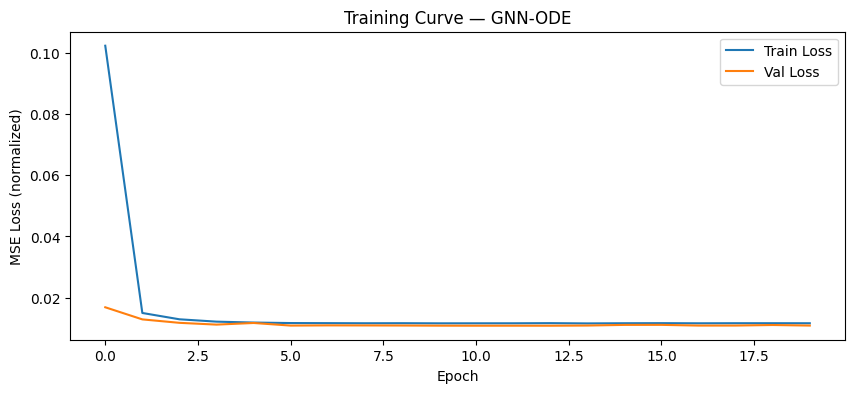

In [ ]:
model.load_state_dict(torch.load('best_gnn_ode_model.pt'))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        pred = model(x_batch, t_span).cpu().numpy()
        all_preds.append(pred)
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Denormalisasi kembali ke km/h
all_preds_kph = all_preds * train_std + train_mean
all_targets_kph = all_targets * train_std + train_mean

mae = np.mean(np.abs(all_preds_kph - all_targets_kph))
rmse = np.sqrt(np.mean((all_preds_kph - all_targets_kph) ** 2))

print(f"\n=== Evaluasi Test Set ===")
print(f"MAE: {mae:.2f} km/h")
print(f"RMSE: {rmse:.2f} km/h")

# Plot training curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training Curve — GNN-ODE')
plt.legend()
plt.savefig('training_curve.png', dpi=150)
plt.show()

In [ ]:
# ===== Setup bersama: timestamp tiap sample di test set =====
# DataLoader test_loader pakai shuffle=False, jadi urutan all_preds_kph /
# all_targets_kph mengikuti urutan index sekuensial test_dataset (0..N-1)
test_timestamps = test_df.index[seq_len + horizon - 1 : seq_len + horizon - 1 + len(test_dataset)]
test_hours = pd.to_datetime(test_timestamps).hour
test_minute_bins = pd.to_datetime(test_timestamps).minute // 5 * 5

print(f"Jumlah sample test: {len(test_timestamps)}")
print(f"Rentang waktu test: {test_timestamps.min()} s/d {test_timestamps.max()}")

Jumlah sample test: 276
Rentang waktu test: 2026-01-12 01:00:00 s/d 2026-01-12 23:55:00


## **4.5 Baseline Pembanding: Rata-rata Historis**

**Teknik Code:** `groupby(['hour','minute_bin']).mean()` dari data train

**Cara Kerja:** Membuat baseline sederhana: prediksi = rata-rata kecepatan historis pada jam & menit yang sama (dari data train), lalu dibandingkan MAE-nya dengan model GNN-ODE untuk membuktikan model lebih baik dari sekadar tabel lookup statistik.

In [ ]:
# ===== Baseline Pembanding: Rata-rata Historis per Jam (dari TRAIN) =====
# Baseline paling murah & standar untuk traffic forecasting: prediksi = rata-rata
# speed pada jam & menit yang sama, dihitung dari data TRAIN saja (bukan model).
train_df_idx = train_df.copy()
train_df_idx.index = pd.to_datetime(train_df_idx.index)
train_df_idx['hour'] = train_df_idx.index.hour
train_df_idx['minute_bin'] = train_df_idx.index.minute // 5 * 5

node_cols = [c for c in train_df_idx.columns if c not in ('hour', 'minute_bin')]
hourly_avg_per_node = train_df_idx.groupby(['hour', 'minute_bin'])[node_cols].mean()

baseline_preds = np.array([
    hourly_avg_per_node.loc[(h, m)].values
    for h, m in zip(test_hours, test_minute_bins)
])  # [n_samples, num_nodes], sudah dalam satuan km/h

mae_baseline = np.mean(np.abs(baseline_preds - all_targets_kph))
rmse_baseline = np.sqrt(np.mean((baseline_preds - all_targets_kph) ** 2))

print("=== Perbandingan Model vs Baseline (Rata-rata Historis per Jam) ===")
print(f"GNN-ODE            : MAE={mae:.2f} km/h, RMSE={rmse:.2f} km/h")
print(f"Baseline (avg jam) : MAE={mae_baseline:.2f} km/h, RMSE={rmse_baseline:.2f} km/h")
if mae < mae_baseline:
    improvement = (1 - mae / mae_baseline) * 100
    print(f"\n-> GNN-ODE lebih baik {improvement:.1f}% dibanding baseline sederhana.")
else:
    gap = (mae / mae_baseline - 1) * 100
    print(f"\n-> PERINGATAN: GNN-ODE {gap:.1f}% LEBIH BURUK dari baseline sederhana.")
    print("   Model belum terbukti bernilai lebih dari lookup statistik jam-of-day.")
    print("   Pertimbangkan tuning hidden_dim, jumlah epoch, atau cek data leakage.")

=== Perbandingan Model vs Baseline (Rata-rata Historis per Jam) ===
GNN-ODE            : MAE=0.60 km/h, RMSE=0.78 km/h
Baseline (avg jam) : MAE=5.13 km/h, RMSE=6.16 km/h

-> GNN-ODE lebih baik 88.3% dibanding baseline sederhana.


## **4.6 Evaluasi Multi-Horizon**

**Teknik Code:** `odeint()` dengan `t_span` berisi banyak titik waktu sekaligus (t=1,2,3)

**Cara Kerja:** Karena sifat ODE kontinu, satu forward pass model bisa diintegrasikan ke beberapa horizon waktu berbeda (5, 10, 15 menit) sekaligus tanpa retrain model terpisah — dievaluasi MAE/RMSE per horizon untuk membuktikan keunggulan pendekatan continuous-time.

=== Evaluasi Multi-Horizon (1 model, integrasi ODE ke t berbeda) ===
Horizon 5 menit: MAE=0.60 km/h, RMSE=0.78 km/h
Horizon 10 menit: MAE=1.06 km/h, RMSE=1.33 km/h
Horizon 15 menit: MAE=1.61 km/h, RMSE=2.16 km/h

Interpretasi: MAE yang naik bertahap dari horizon 5->10->15 menit itu wajar
(prediksi makin jauh makin tidak pasti). Yang penting: prediksi ini didapat dari
SATU forward pass model yang sama, bukan 3 model terpisah -- ini bukti nyata
keunggulan continuous-time yang jadi klaim utama arsitektur GNN-ODE.


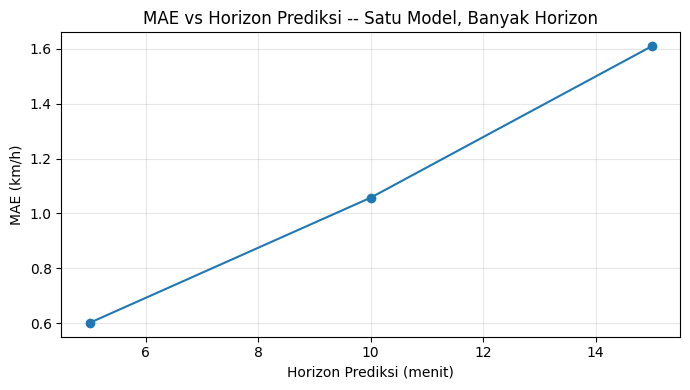

In [ ]:
HORIZONS = [1, 2, 3]  # dalam step 5 menit -> 5, 10, 15 menit ke depan
t_span_multi = torch.tensor([0.] + [float(h) for h in HORIZONS]).to(device)

model.eval()
max_h = max(HORIZONS)
n_test = len(test_norm)

multi_preds = {h: [] for h in HORIZONS}
multi_targets = {h: [] for h in HORIZONS}

with torch.no_grad():
    for start in range(0, n_test - seq_len - max_h, 4):  # stride 4 biar tidak terlalu berat
        x = torch.tensor(test_norm[start:start + seq_len], dtype=torch.float32).unsqueeze(0).to(device)
        h0 = x[:, -1, :].unsqueeze(-1)
        h0 = model.encoder(h0)
        h_traj = odeint(model.odefunc, h0[0], t_span_multi, method=model.solver)  # [len(t_span), num_nodes, hidden]
        for i, h in enumerate(HORIZONS):
            pred = model.decoder(h_traj[i + 1]).squeeze(-1).cpu().numpy()  # index 0 = t=0 (skip)
            target = test_norm[start + seq_len + h - 1]
            multi_preds[h].append(pred)
            multi_targets[h].append(target)

print("=== Evaluasi Multi-Horizon (1 model, integrasi ODE ke t berbeda) ===")
horizon_maes = {}
for h in HORIZONS:
    preds_h = np.array(multi_preds[h]) * train_std + train_mean
    targets_h = np.array(multi_targets[h]) * train_std + train_mean
    mae_h = np.mean(np.abs(preds_h - targets_h))
    rmse_h = np.sqrt(np.mean((preds_h - targets_h) ** 2))
    horizon_maes[h] = mae_h
    print(f"Horizon {h*5} menit: MAE={mae_h:.2f} km/h, RMSE={rmse_h:.2f} km/h")

print("\nInterpretasi: MAE yang naik bertahap dari horizon 5->10->15 menit itu wajar\n"
      "(prediksi makin jauh makin tidak pasti). Yang penting: prediksi ini didapat dari\n"
      "SATU forward pass model yang sama, bukan 3 model terpisah -- ini bukti nyata\n"
      "keunggulan continuous-time yang jadi klaim utama arsitektur GNN-ODE.")

# Visualisasi
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([h * 5 for h in HORIZONS], [horizon_maes[h] for h in HORIZONS], marker='o')
ax.set_xlabel('Horizon Prediksi (menit)')
ax.set_ylabel('MAE (km/h)')
ax.set_title('MAE vs Horizon Prediksi -- Satu Model, Banyak Horizon')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multi_horizon_mae.png', dpi=150)
plt.show()

## **4.7 Breakdown Evaluasi Jam Sibuk vs Non-Sibuk**

**Teknik Code:** Boolean masking `(is_peak())` pada array prediksi

**Cara Kerja:** Memisahkan hasil prediksi menjadi kelompok jam sibuk (07-09, 16-19) dan non-sibuk, lalu membandingkan MAE keduanya untuk melihat apakah model tetap akurat saat kondisi macet — kasus penggunaan paling krusial.

=== Breakdown Evaluasi: Jam Sibuk (07-09, 16-19) vs Non-Sibuk ===
Jam Sibuk    : MAE=0.70 km/h, RMSE=0.89 km/h, n=84
Non-Sibuk    : MAE=0.55 km/h, RMSE=0.72 km/h, n=192

-> Error saat jam sibuk 26.5% lebih tinggi dari non-sibuk.
   Wajar (variabilitas lebih tinggi saat macet), tapi ini justru bagian
   paling penting untuk use-case deteksi kemacetan -- pertimbangkan
   weighted loss atau data augmentation utk jam sibuk kalau gap besar.


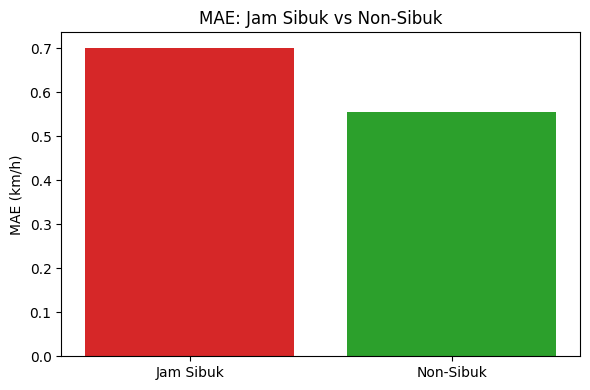

In [ ]:
def is_peak(hour):
    return (7 <= hour <= 9) or (16 <= hour <= 19)

peak_mask = np.array([is_peak(h) for h in test_hours])

mae_peak = np.mean(np.abs(all_preds_kph[peak_mask] - all_targets_kph[peak_mask]))
mae_offpeak = np.mean(np.abs(all_preds_kph[~peak_mask] - all_targets_kph[~peak_mask]))
rmse_peak = np.sqrt(np.mean((all_preds_kph[peak_mask] - all_targets_kph[peak_mask]) ** 2))
rmse_offpeak = np.sqrt(np.mean((all_preds_kph[~peak_mask] - all_targets_kph[~peak_mask]) ** 2))

print("=== Breakdown Evaluasi: Jam Sibuk (07-09, 16-19) vs Non-Sibuk ===")
print(f"Jam Sibuk    : MAE={mae_peak:.2f} km/h, RMSE={rmse_peak:.2f} km/h, n={peak_mask.sum()}")
print(f"Non-Sibuk    : MAE={mae_offpeak:.2f} km/h, RMSE={rmse_offpeak:.2f} km/h, n={(~peak_mask).sum()}")

if mae_peak > mae_offpeak:
    gap = (mae_peak / mae_offpeak - 1) * 100
    print(f"\n-> Error saat jam sibuk {gap:.1f}% lebih tinggi dari non-sibuk.")
    print("   Wajar (variabilitas lebih tinggi saat macet), tapi ini justru bagian")
    print("   paling penting untuk use-case deteksi kemacetan -- pertimbangkan")
    print("   weighted loss atau data augmentation utk jam sibuk kalau gap besar.")
else:
    print("\n-> Model justru lebih akurat saat jam sibuk dibanding non-sibuk.")

# Visualisasi
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Jam Sibuk', 'Non-Sibuk'], [mae_peak, mae_offpeak], color=['#d62728', '#2ca02c'])
ax.set_ylabel('MAE (km/h)')
ax.set_title('MAE: Jam Sibuk vs Non-Sibuk')
plt.tight_layout()
plt.savefig('mae_peak_vs_offpeak.png', dpi=150)
plt.show()

## **4.8.1 Validasi Struktur Spasial**

**Teknik Code:** `networkx.shortest_path_length()` untuk sampling pasangan node dekat vs jauh + perbandingan korelasi

**Cara Kerja:** Mengambil sampel pasangan node bertetangga (1-hop) dan pasangan node jauh (≥4 hop), lalu membandingkan korelasi kecepatan aktual vs korelasi hasil prediksi model vs baseline persistence — untuk membuktikan model benar-benar belajar propagasi spasial di graf, bukan hanya pola waktu per-node.



Graph index: 2669 nodes, 3658 edges
Pasangan tetangga (1-hop): 300 | Pasangan jauh (>=4 hop): 300

=== Korelasi AKTUAL (ground truth, test set) ===
Tetangga (1-hop), n=300: mean corr = 0.898
Jauh (>=4 hop),  n=300: mean corr = 0.787

=== Korelasi PREDIKSI MODEL ===
Tetangga (1-hop): mean corr = 0.903
Jauh (>=4 hop):  mean corr = 0.797

=== Korelasi BASELINE PERSISTENCE (kontrol pembanding) ===
Tetangga (1-hop): mean corr = 0.898
Jauh (>=4 hop):  mean corr = 0.788

=== Ringkasan Gap (Tetangga - Jauh) ===
Aktual (ground truth) : +0.111
Prediksi GNN-ODE       : +0.106
Baseline persistence   : +0.110

Interpretasi: kalau gap GNN-ODE mendekati gap Aktual dan LEBIH BESAR
dari gap baseline persistence, itu bukti model memanfaatkan struktur
graf (propagasi spasial), bukan cuma menghafal pola waktu per-node.
Kalau gap GNN-ODE mirip/lebih kecil dari baseline persistence, berarti
kontribusi komponen GCN-ODE terhadap 'propagasi' belum terbukti kuat --
pertimbangkan tuning hidden_dim, jumlah layer 

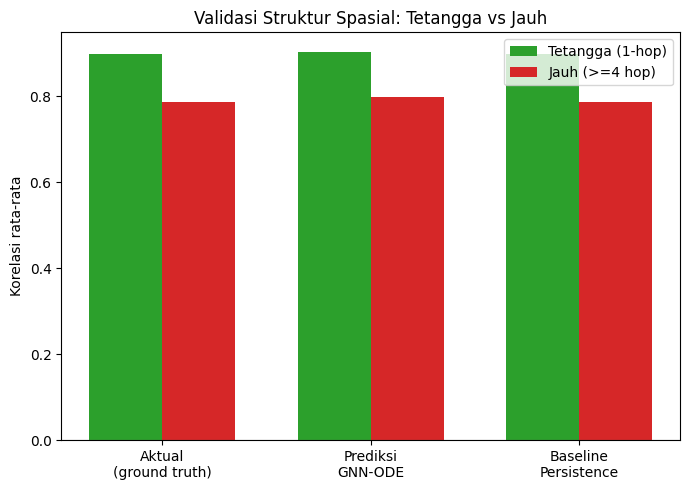

In [ ]:
import networkx as nx
from itertools import combinations
import random

random.seed(42)

# ===== 1. Bangun graph node-level dari edge_index (untuk hitung jarak topologi) =====
G_idx = nx.Graph()
G_idx.add_nodes_from(range(config['num_nodes']))
edge_pairs = edge_index.cpu().numpy().T
G_idx.add_edges_from([tuple(e) for e in edge_pairs])

print(f"Graph index: {G_idx.number_of_nodes()} nodes, {G_idx.number_of_edges()} edges")

# ===== 2. Sample pasangan node: 'tetangga' (1-hop) vs 'jauh' (>=4 hop) =====
N_PAIRS = 300  # cukup untuk estimasi korelasi rata-rata, sesuaikan kalau graph kecil

adjacent_pairs = list(G_idx.edges())
random.shuffle(adjacent_pairs)
adjacent_pairs = adjacent_pairs[:N_PAIRS]

all_nodes = list(G_idx.nodes())
distant_pairs = []
attempts = 0
while len(distant_pairs) < N_PAIRS and attempts < N_PAIRS * 50:
    a, b = random.sample(all_nodes, 2)
    attempts += 1
    try:
        d = nx.shortest_path_length(G_idx, a, b)
    except nx.NetworkXNoPath:
        continue
    if d >= 4:
        distant_pairs.append((a, b))

print(f"Pasangan tetangga (1-hop): {len(adjacent_pairs)} | Pasangan jauh (>=4 hop): {len(distant_pairs)}")

# ===== 3. Korelasi AKTUAL (ground truth) dari test set =====
# test_df: [timestamps, num_nodes] -- kolom = node index
def mean_corr(pairs, matrix_df):
    corrs = []
    for a, b in pairs:
        if a in matrix_df.columns and b in matrix_df.columns:
            c = matrix_df[a].corr(matrix_df[b])
            if not np.isnan(c):
                corrs.append(c)
    return np.mean(corrs), len(corrs)

actual_adj_corr, n1 = mean_corr(adjacent_pairs, test_df)
actual_far_corr, n2 = mean_corr(distant_pairs, test_df)

print("\n=== Korelasi AKTUAL (ground truth, test set) ===")
print(f"Tetangga (1-hop), n={n1}: mean corr = {actual_adj_corr:.3f}")
print(f"Jauh (>=4 hop),  n={n2}: mean corr = {actual_far_corr:.3f}")

# ===== 4. Korelasi hasil PREDIKSI model =====
# all_preds_kph: [n_test_samples, num_nodes] -- hasil dari cell evaluasi sebelumnya
pred_df = pd.DataFrame(all_preds_kph, columns=range(all_preds_kph.shape[1]))

pred_adj_corr, _ = mean_corr(adjacent_pairs, pred_df)
pred_far_corr, _ = mean_corr(distant_pairs, pred_df)

print("\n=== Korelasi PREDIKSI MODEL ===")
print(f"Tetangga (1-hop): mean corr = {pred_adj_corr:.3f}")
print(f"Jauh (>=4 hop):  mean corr = {pred_far_corr:.3f}")

# ===== 5. Baseline naif: persistence (nilai step terakhir sbg prediksi) =====
# Kalau model 'curang' cuma niru pola waktu, baseline persistence pun akan
# menunjukkan gap tetangga-vs-jauh yang mirip -- jadi ini kontrol pembanding.
persist_pred = test_df.shift(1).dropna()
persist_adj_corr, _ = mean_corr(adjacent_pairs, persist_pred)
persist_far_corr, _ = mean_corr(distant_pairs, persist_pred)

print("\n=== Korelasi BASELINE PERSISTENCE (kontrol pembanding) ===")
print(f"Tetangga (1-hop): mean corr = {persist_adj_corr:.3f}")
print(f"Jauh (>=4 hop):  mean corr = {persist_far_corr:.3f}")

# ===== 6. Ringkasan gap tetangga vs jauh =====
print("\n=== Ringkasan Gap (Tetangga - Jauh) ===")
print(f"Aktual (ground truth) : {actual_adj_corr - actual_far_corr:+.3f}")
print(f"Prediksi GNN-ODE       : {pred_adj_corr - pred_far_corr:+.3f}")
print(f"Baseline persistence   : {persist_adj_corr - persist_far_corr:+.3f}")
print("\nInterpretasi: kalau gap GNN-ODE mendekati gap Aktual dan LEBIH BESAR\n"
      "dari gap baseline persistence, itu bukti model memanfaatkan struktur\n"
      "graf (propagasi spasial), bukan cuma menghafal pola waktu per-node.\n"
      "Kalau gap GNN-ODE mirip/lebih kecil dari baseline persistence, berarti\n"
      "kontribusi komponen GCN-ODE terhadap 'propagasi' belum terbukti kuat --\n"
      "pertimbangkan tuning hidden_dim, jumlah layer GCN, atau t_span integrasi."
)

# ===== 7. Visualisasi ringkas =====
fig, ax = plt.subplots(figsize=(7, 5))
groups = ['Aktual\n(ground truth)', 'Prediksi\nGNN-ODE', 'Baseline\nPersistence']
adj_vals = [actual_adj_corr, pred_adj_corr, persist_adj_corr]
far_vals = [actual_far_corr, pred_far_corr, persist_far_corr]

x = np.arange(len(groups))
width = 0.35
ax.bar(x - width/2, adj_vals, width, label='Tetangga (1-hop)', color='#2ca02c')
ax.bar(x + width/2, far_vals, width, label='Jauh (>=4 hop)', color='#d62728')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Korelasi rata-rata')
ax.set_title('Validasi Struktur Spasial: Tetangga vs Jauh')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig('spatial_structure_validation.png', dpi=150)
plt.show()

## **4.8.2 Model Pembanding LSTM**

**Teknik Code:** `nn.LSTM + nn.Linear` decoder, training loop terpisah (variabel` lstm_*`)

**Cara Kerja:** Melatih model LSTM sederhana yang memprediksi semua node sekaligus dari sequence historis TANPA memakai struktur graf, sebagai pembanding neural non-graph terhadap GNN-ODE.

In [ ]:
class LSTMForecast(nn.Module):
    """Baseline neural: prediksi semua node sekaligus dari sequence historis,
    TANPA memanfaatkan struktur graf (edge_index) sama sekali."""
    def __init__(self, num_nodes, hidden_dim=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_nodes, hidden_size=hidden_dim,
                             num_layers=num_layers, batch_first=True)
        self.decoder = nn.Linear(hidden_dim, num_nodes)

    def forward(self, x):
        # x: [batch, seq_len, num_nodes]
        out, _ = self.lstm(x)
        pred = self.decoder(out[:, -1, :])  # ambil hidden state terakhir
        return pred

torch.manual_seed(42)
lstm_model = LSTMForecast(num_nodes=config['num_nodes'], hidden_dim=64).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_loss_fn = nn.MSELoss()

n_epochs_lstm, patience_lstm = 50, 7
best_val_loss_lstm, patience_counter_lstm = float('inf'), 0
lstm_train_losses, lstm_val_losses = [], []

for epoch in range(n_epochs_lstm):
    lstm_model.train()
    epoch_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        lstm_optimizer.zero_grad()
        pred = lstm_model(x_batch)
        loss = lstm_loss_fn(pred, y_batch)
        loss.backward()
        lstm_optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    lstm_model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = lstm_model(x_batch)
            loss = lstm_loss_fn(pred, y_batch)
            epoch_val_loss += loss.item()
    epoch_val_loss /= len(val_loader)

    lstm_train_losses.append(epoch_train_loss)
    lstm_val_losses.append(epoch_val_loss)
    print(f"[LSTM] Epoch {epoch+1}/{n_epochs_lstm} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss_lstm:
        best_val_loss_lstm = epoch_val_loss
        patience_counter_lstm = 0
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pt')
    else:
        patience_counter_lstm += 1
        if patience_counter_lstm >= patience_lstm:
            print(f"Early stopping LSTM di epoch {epoch+1}")
            break

print(f"\nLSTM training selesai. Best val loss: {best_val_loss_lstm:.4f}")

[LSTM] Epoch 1/50 | Train: 0.3638 | Val: 0.4438
[LSTM] Epoch 2/50 | Train: 0.1180 | Val: 0.4000
[LSTM] Epoch 3/50 | Train: 0.0847 | Val: 0.3666
[LSTM] Epoch 4/50 | Train: 0.0713 | Val: 0.3559
[LSTM] Epoch 5/50 | Train: 0.0605 | Val: 0.3411
[LSTM] Epoch 6/50 | Train: 0.0558 | Val: 0.3361
[LSTM] Epoch 7/50 | Train: 0.0527 | Val: 0.3261
[LSTM] Epoch 8/50 | Train: 0.0498 | Val: 0.3267
[LSTM] Epoch 9/50 | Train: 0.0465 | Val: 0.3250
[LSTM] Epoch 10/50 | Train: 0.0435 | Val: 0.3257
[LSTM] Epoch 11/50 | Train: 0.0417 | Val: 0.3296
[LSTM] Epoch 12/50 | Train: 0.0404 | Val: 0.3263
[LSTM] Epoch 13/50 | Train: 0.0395 | Val: 0.3242
[LSTM] Epoch 14/50 | Train: 0.0390 | Val: 0.3202
[LSTM] Epoch 15/50 | Train: 0.0380 | Val: 0.3280
[LSTM] Epoch 16/50 | Train: 0.0374 | Val: 0.3271
[LSTM] Epoch 17/50 | Train: 0.0361 | Val: 0.3223
[LSTM] Epoch 18/50 | Train: 0.0358 | Val: 0.3289
[LSTM] Epoch 19/50 | Train: 0.0351 | Val: 0.3196
[LSTM] Epoch 20/50 | Train: 0.0342 | Val: 0.3142
[LSTM] Epoch 21/50 | Train: 0

In [ ]:
# ===== Evaluasi LSTM (variabel nama berbeda dari GNN-ODE, tidak menimpa apa pun) =====
lstm_model.load_state_dict(torch.load('best_lstm_model.pt'))
lstm_model.eval()

all_preds_lstm, all_targets_lstm = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        pred = lstm_model(x_batch).cpu().numpy()
        all_preds_lstm.append(pred)
        all_targets_lstm.append(y_batch.numpy())

all_preds_lstm = np.concatenate(all_preds_lstm, axis=0)
all_targets_lstm = np.concatenate(all_targets_lstm, axis=0)

all_preds_kph_lstm = all_preds_lstm * train_std + train_mean
all_targets_kph_lstm = all_targets_lstm * train_std + train_mean  # identik dgn all_targets_kph GNN-ODE

mae_lstm = np.mean(np.abs(all_preds_kph_lstm - all_targets_kph_lstm))
rmse_lstm = np.sqrt(np.mean((all_preds_kph_lstm - all_targets_kph_lstm) ** 2))

print("=== Evaluasi LSTM (Test Set) ===")
print(f"MAE: {mae_lstm:.2f} km/h")
print(f"RMSE: {rmse_lstm:.2f} km/h")

=== Evaluasi LSTM (Test Set) ===
MAE: 4.04 km/h
RMSE: 5.22 km/h


## **4.8.3 Model Pembanding ARIMA**

**Teknik Code:** `statsmodels.tsa.arima.model.ARIMA` (order 2,1,1), rolling forecast dengan `.append(refit=False)`

**Cara Kerja:** Melatih model ARIMA klasik per-node (disampling 20 node karena mahal komputasi), melakukan forecast satu-langkah berulang sambil meng-update state model dengan observasi baru tanpa refit penuh, sebagai pembanding model statistik klasik non-deep-learning.

In [ ]:
!pip install statsmodels -q
from statsmodels.tsa.arima.model import ARIMA
import warnings, random
warnings.filterwarnings('ignore')

# ARIMA per-node cukup mahal komputasi kalau dijalankan ke SEMUA node --
# jadi di-sample ke sejumlah node representatif. Ini estimasi, bukan evaluasi
# penuh jaringan (beda scope dari MAE GNN-ODE/LSTM/baseline yang full-network).
ARIMA_MAX_NODES = 20
sample_nodes = list(range(config['num_nodes']))
random.Random(42).shuffle(sample_nodes)
sample_nodes = sample_nodes[:ARIMA_MAX_NODES]

print(f"Menjalankan ARIMA(2,1,1) pada {len(sample_nodes)} node sample dari {config['num_nodes']} total node")
print("(rolling one-step-ahead forecast, update state pakai .append(refit=False) -- tanpa refit penuh tiap step)")

mask_idx = test_df.index.isin(test_timestamps)
arima_preds_by_node, arima_targets_by_node = {}, {}

for node in sample_nodes:
    train_series = train_df[node].values
    test_series_full = test_df[node].values

    try:
        arima_res = ARIMA(train_series, order=(2, 1, 1)).fit()
    except Exception as e:
        print(f"Node {node} gagal fit ARIMA: {e}")
        continue

    preds = []
    current_res = arima_res
    for t in range(len(test_series_full)):
        fc = current_res.forecast(steps=1)[0]
        preds.append(fc)
        current_res = current_res.append([test_series_full[t]], refit=False)

    preds = np.array(preds)
    # subset ke timestamp yang SAMA dengan target GNN-ODE/LSTM (apples-to-apples)
    arima_preds_by_node[node] = preds[mask_idx]
    arima_targets_by_node[node] = test_series_full[mask_idx]

arima_all_errors = np.concatenate([
    arima_preds_by_node[n] - arima_targets_by_node[n] for n in arima_preds_by_node
])

mae_arima = np.mean(np.abs(arima_all_errors))
rmse_arima = np.sqrt(np.mean(arima_all_errors ** 2))

print(f"\n=== Evaluasi ARIMA (sample {len(arima_preds_by_node)} node, timestamp sama dgn GNN-ODE) ===")
print(f"MAE: {mae_arima:.2f} km/h")
print(f"RMSE: {rmse_arima:.2f} km/h")

Menjalankan ARIMA(2,1,1) pada 20 node sample dari 2669 total node
(rolling one-step-ahead forecast, update state pakai .append(refit=False) -- tanpa refit penuh tiap step)

=== Evaluasi ARIMA (sample 20 node, timestamp sama dgn GNN-ODE) ===
MAE: 0.63 km/h
RMSE: 0.82 km/h


## **4.9 Tabel & Grafik Perbandingan Akhir**

**Teknik Code:** `pandas.DataFrame` ringkasan +` matplotlib` bar chart ganda

**Cara Kerja:** Menyusun dua tabel perbandingan: (a) full-network (GNN-ODE vs LSTM vs Baseline) dan (b) apples-to-apples pada node sample yang sama dengan ARIMA, divisualisasikan sebagai bar chart berdampingan untuk perbandingan MAE yang adil antar keempat model.

=== (a) Perbandingan Full-Network (tanpa ARIMA -- ARIMA cuma di-sample) ===
             Model  MAE (km/h)  RMSE (km/h)    Cakupan
           GNN-ODE    0.599367     0.778675 Semua node
              LSTM    4.043916     5.220584 Semua node
Baseline (avg jam)    5.130683     6.164103 Semua node

=== (b) Perbandingan Adil (apples-to-apples, node sama dgn ARIMA) ===
             Model  MAE (km/h)        Cakupan
           GNN-ODE    0.678882 20 node sample
              LSTM    4.061275 20 node sample
Baseline (avg jam)    5.373154 20 node sample
             ARIMA    0.625422 20 node sample


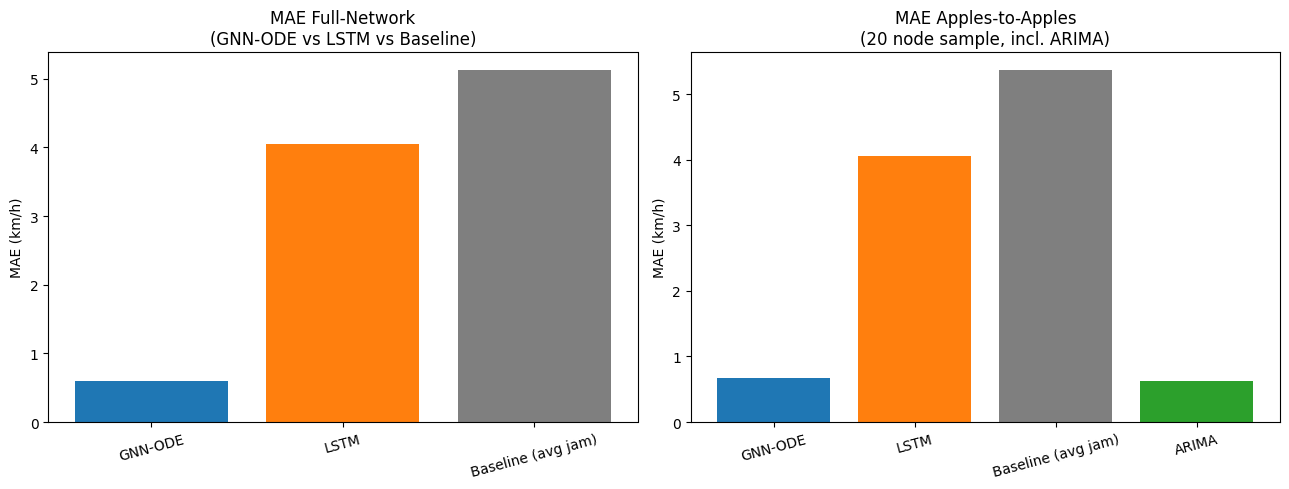


Catatan: panel kiri pakai seluruh node (ARIMA tidak diikutkan krn cuma di-sample).
Panel kanan itu perbandingan yang PALING ADIL karena keempat model dievaluasi
pada node & timestamp yang persis sama.


In [ ]:
comparison_full = pd.DataFrame({
    'Model': ['GNN-ODE', 'LSTM', 'Baseline (avg jam)'],
    'MAE (km/h)': [mae, mae_lstm, mae_baseline],
    'RMSE (km/h)': [rmse, rmse_lstm, rmse_baseline],
    'Cakupan': ['Semua node', 'Semua node', 'Semua node'],
})

# (b) Perbandingan APPLES-TO-APPLES: hanya node yang sama dgn sample ARIMA
sample_idx = np.array(sample_nodes)
mae_ode_sample = np.mean(np.abs(all_preds_kph[:, sample_idx] - all_targets_kph[:, sample_idx]))
mae_lstm_sample = np.mean(np.abs(all_preds_kph_lstm[:, sample_idx] - all_targets_kph_lstm[:, sample_idx]))
mae_baseline_sample = np.mean(np.abs(baseline_preds[:, sample_idx] - all_targets_kph[:, sample_idx]))

comparison_sample = pd.DataFrame({
    'Model': ['GNN-ODE', 'LSTM', 'Baseline (avg jam)', 'ARIMA'],
    'MAE (km/h)': [mae_ode_sample, mae_lstm_sample, mae_baseline_sample, mae_arima],
    'Cakupan': [f'{len(sample_idx)} node sample']*4,
})

print("=== (a) Perbandingan Full-Network (tanpa ARIMA -- ARIMA cuma di-sample) ===")
print(comparison_full.to_string(index=False))
print("\n=== (b) Perbandingan Adil (apples-to-apples, node sama dgn ARIMA) ===")
print(comparison_sample.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(comparison_full['Model'], comparison_full['MAE (km/h)'], color=['#1f77b4', '#ff7f0e', '#7f7f7f'])
axes[0].set_title('MAE Full-Network\n(GNN-ODE vs LSTM vs Baseline)')
axes[0].set_ylabel('MAE (km/h)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comparison_sample['Model'], comparison_sample['MAE (km/h)'],
            color=['#1f77b4', '#ff7f0e', '#7f7f7f', '#2ca02c'])
axes[1].set_title(f'MAE Apples-to-Apples\n({len(sample_idx)} node sample, incl. ARIMA)')
axes[1].set_ylabel('MAE (km/h)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150)
plt.show()

print("\nCatatan: panel kiri pakai seluruh node (ARIMA tidak diikutkan krn cuma di-sample).\n"
      "Panel kanan itu perbandingan yang PALING ADIL karena keempat model dievaluasi\n"
      "pada node & timestamp yang persis sama.")